<a href="https://colab.research.google.com/github/MidhulaMS/EV-Population-Prediction/blob/Midhula.Model_Building_Decision_Tree/EV_Population_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries

In [3]:
from google.colab import drive
drive.mount('/content/drive')

In [4]:
#from google.colab import drive
#drive.mount('/content/drive')

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

# Cross - validation, hyperparameter tuning (k-fold,grid)
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, RandomizedSearchCV

# Logistic Regression
from sklearn.linear_model import LogisticRegression
# k-NN
from sklearn.neighbors import KNeighborsClassifier
# Decision Tree
from sklearn.tree import DecisionTreeClassifier
# Random Forest
from sklearn.ensemble import RandomForestClassifier


# Bagging
from sklearn.ensemble import BaggingClassifier
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
# Boosting
from sklearn.ensemble import AdaBoostClassifier



# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# For evaluating Mode
from statistics import mode

# For min max scaling
from sklearn.preprocessing import MinMaxScaler

# Reading Data

In [6]:
filepath =  "/content/drive/MyDrive/DATA/export (1).csv"

In [7]:
EV_df = pd.read_csv(filepath)

# Exploratory data analysis (EDA)


In [9]:
EV_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104210 entries, 0 to 104209
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         104210 non-null  object 
 1   County                                             104208 non-null  object 
 2   City                                               104208 non-null  object 
 3   State                                              104210 non-null  object 
 4   Postal Code                                        104208 non-null  float64
 5   Model Year                                         104210 non-null  int64  
 6   Make                                               104210 non-null  object 
 7   Model                                              104210 non-null  object 
 8   Electric Vehicle Type                              104210 non-null  object

In [10]:
EV_df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,YV4H60PE7S,Kitsap,Bremerton,WA,98310.0,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,277607004.0,POINT (-122.61136 47.5752),PUGET SOUND ENERGY INC,5.303508e+10
1,5YJ3E1EB3K,Snohomish,Lynnwood,WA,98087.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,21.0,478641796.0,POINT (-122.27981 47.85727),PUGET SOUND ENERGY INC,5.306104e+10
2,1FADP5CUXD,Kitsap,Port Orchard,WA,98367.0,2013,FORD,C-MAX,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,19.0,35.0,253249678.0,POINT (-122.68471 47.50524),PUGET SOUND ENERGY INC,5.303509e+10
3,5YJSA1H20E,Thurston,Yelm,WA,98597.0,2014,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,208.0,2.0,131872905.0,POINT (-122.60735 46.94239),PUGET SOUND ENERGY INC,5.306701e+10
4,7SAYGDEE2P,Snohomish,Bothell,WA,98012.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,260935657.0,POINT (-122.20105 47.84423),PUGET SOUND ENERGY INC,5.306105e+10


In [11]:
# Numerical Data - Electric Range
# Categorical Data - County,City,State,postal code,Make,Model,ElectricVehicleType,Model Year,CAFV,Eligibility,Electric Utility,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
# Identifiers- VIN,DOL Vehicle ID

In [12]:
EV_df.shape

(104210, 16)

In [13]:
EV_df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,104208.000000,104210.000000,104206.000000,104184.000000,1.042090e+05,1.042070e+05
mean,98204.662425,2022.208253,38.185738,31.296264,2.480545e+08,5.302986e+10
std,841.192110,3.059980,77.592109,14.601036,6.393509e+07,4.596550e+08
min,20736.000000,1999.000000,0.000000,1.000000,1.090490e+05,4.027001e+09
25%,98037.000000,2021.000000,0.000000,20.000000,2.243198e+08,5.303301e+10
50%,98112.000000,2023.000000,0.000000,36.000000,2.649308e+08,5.303302e+10
75%,98292.000000,2024.000000,32.000000,45.000000,2.818646e+08,5.303303e+10
max,99403.000000,2027.000000,337.000000,49.000000,4.789259e+08,5.307794e+10


In [14]:
# Electric Range minimum value is "0" which needs to be inspected.

In [15]:
EV_df.columns

Index(['VIN (1-10)', 'County', 'City', 'State', 'Postal Code', 'Model Year',
       'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Range',
       'Legislative District', 'DOL Vehicle ID', 'Vehicle Location',
       'Electric Utility', '2020 Census Tract'],
      dtype='object')

### finding missing values

In [16]:
EV_df.isna().sum()

,0
VIN (1-10),0
County,2
City,2
State,0
Postal Code,2
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,1


In [17]:
EV_df.duplicated().sum()

np.int64(0)

In [18]:
EV_df['Electric Vehicle Type'].unique()

array(['Plug-in Hybrid Electric Vehicle (PHEV)',
       'Battery Electric Vehicle (BEV)', 'Plug-in Hybrid Electri'],
      dtype=object)

In [19]:
EV_df.nunique()

,0
VIN (1-10),13880
County,51
City,407
State,12
Postal Code,496
Model Year,22
Make,46
Model,190
Electric Vehicle Type,3
Clean Alternative Fuel Vehicle (CAFV) Eligibility,3


In [20]:
EV_df["Electric Vehicle Type"].value_counts(dropna=False)

,count
Electric Vehicle Type,
Battery Electric Vehicle (BEV),84736
Plug-in Hybrid Electric Vehicle (PHEV),19473
Plug-in Hybrid Electri,1


In [21]:
EV_df.duplicated().sum()

np.int64(0)

In [22]:
EV_df["Electric Vehicle Type"].isnull().sum()

np.int64(0)

## Visual EDA(Plotting)

### Univariate analysis

In [23]:
numerical_features = [
    "Electric Range"
]

categorical_features = [
    "County",
    "City",
    "State",
    "Postal Code",
    "Model Year",
    "Make",
    "Model",
    "Electric Vehicle Type",
    "Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    "Legislative District",
    "Electric Utility",
    "Vehicle Location",
    "2020 Census Tract"
]

identifier_features = [
    "VIN (1-10)",
    "DOL Vehicle ID"
]

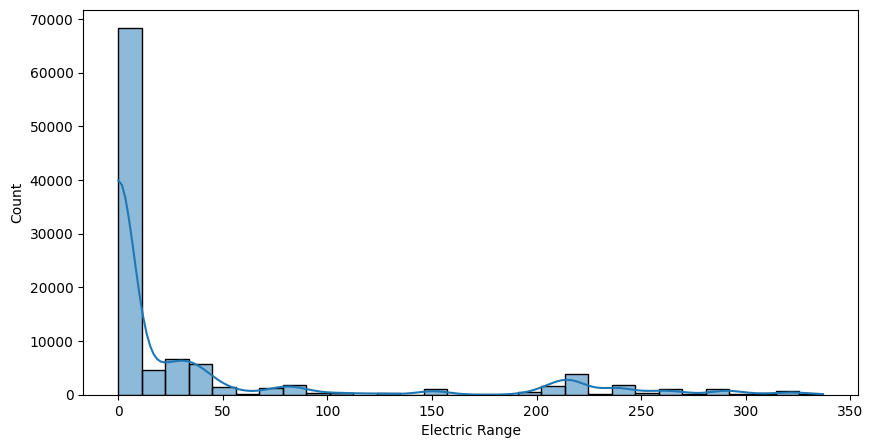

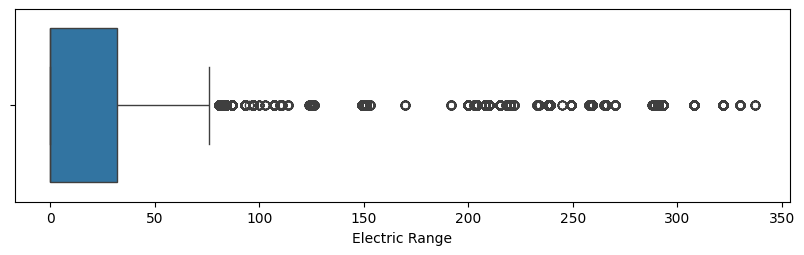

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(EV_df["Electric Range"], kde=True, bins=30)
plt.show()

plt.figure(figsize=(10,2.5))
sns.boxplot(x=EV_df["Electric Range"])
plt.show()

In [25]:
# Data is right skewed since the right whiskers is longer.
# Electric Range contains several high-value outliers.But high range vehicles need to be investigated before treating them as outliers.

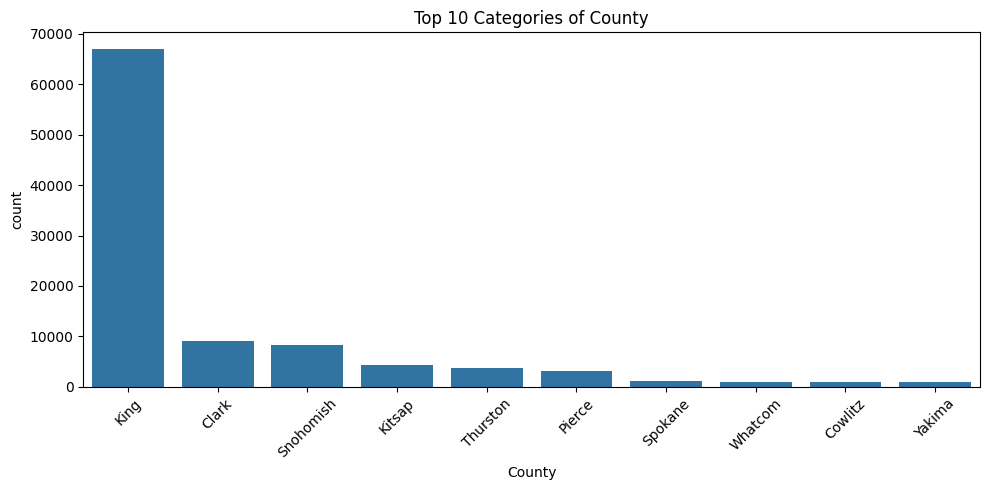

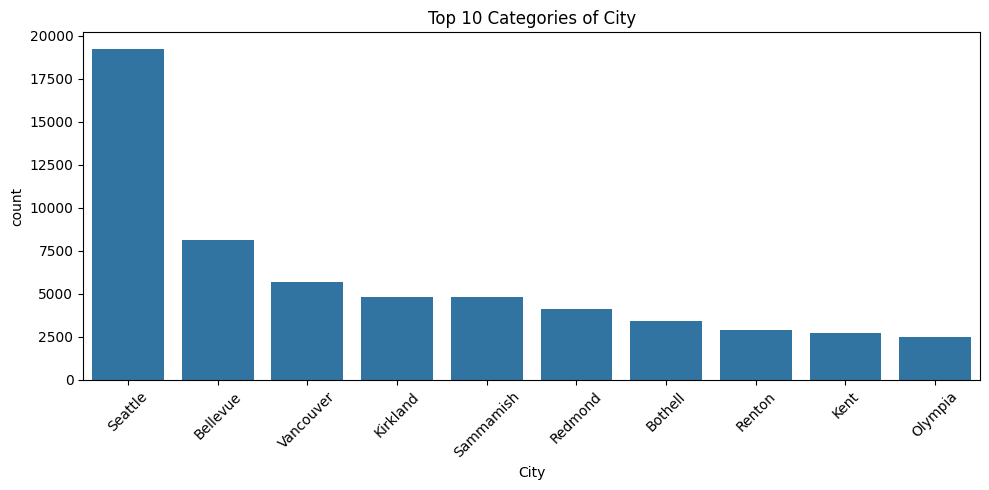

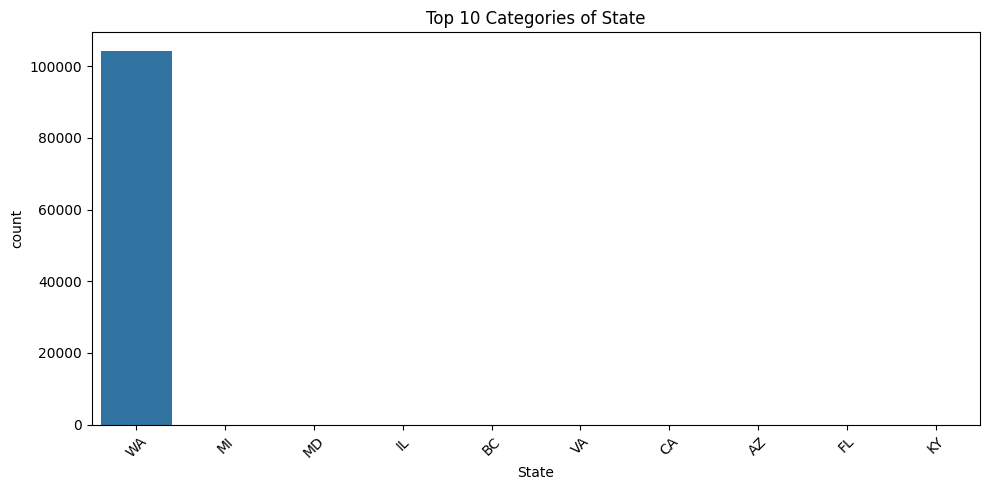

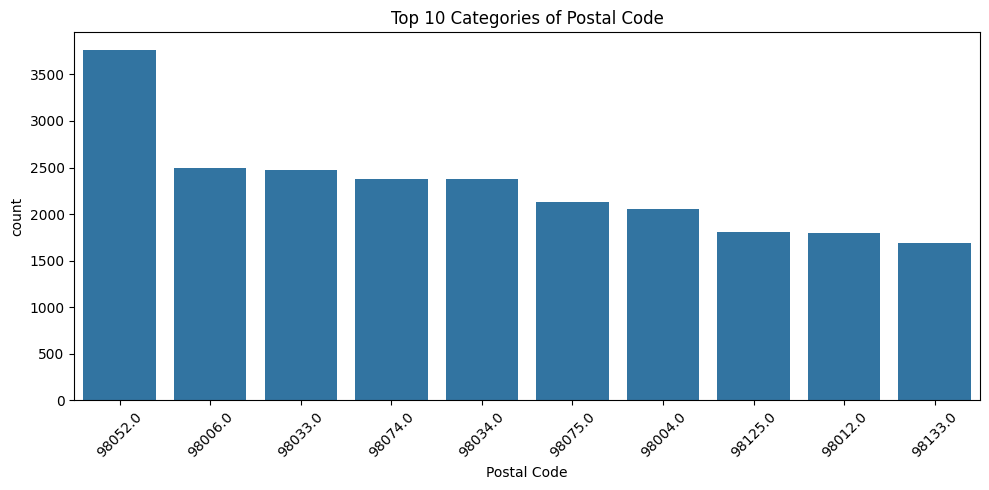

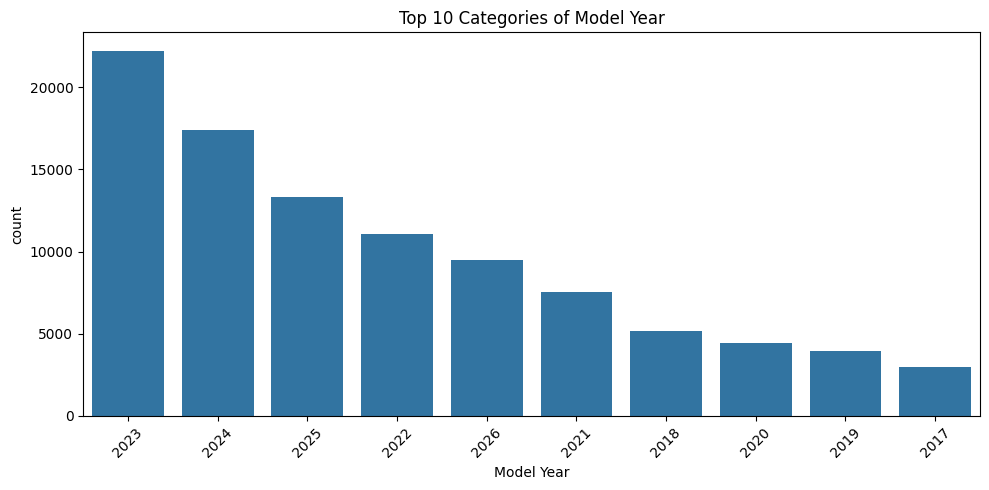

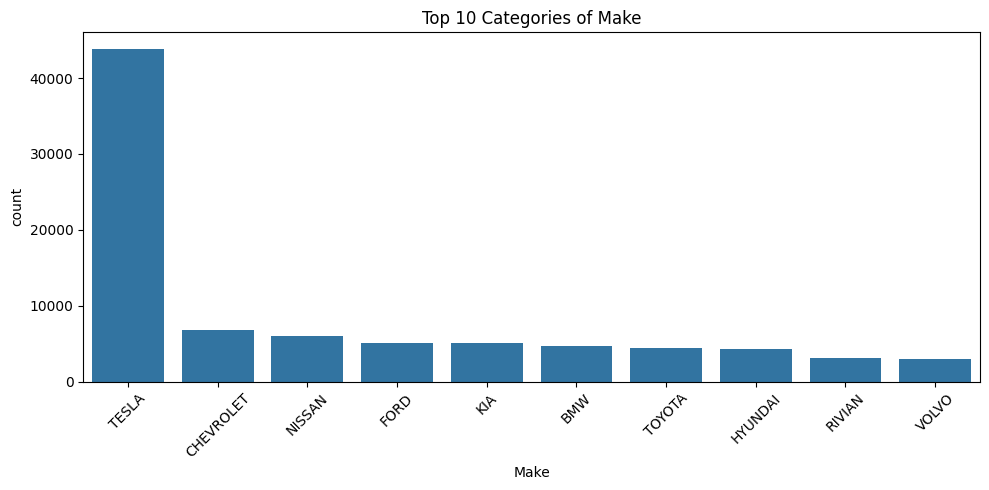

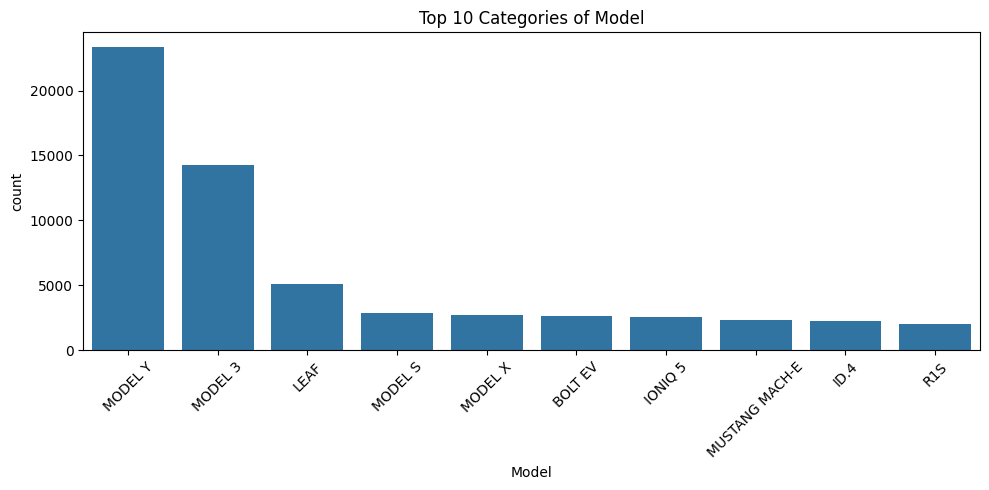

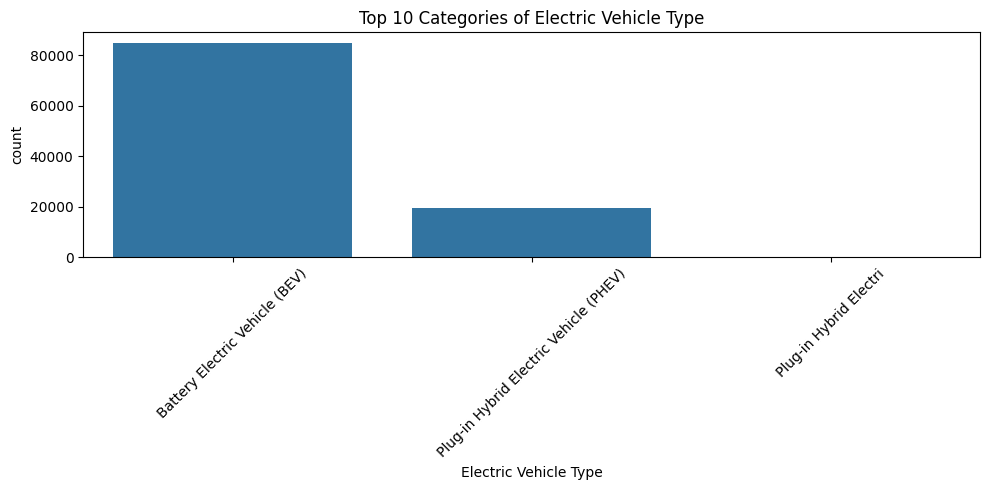

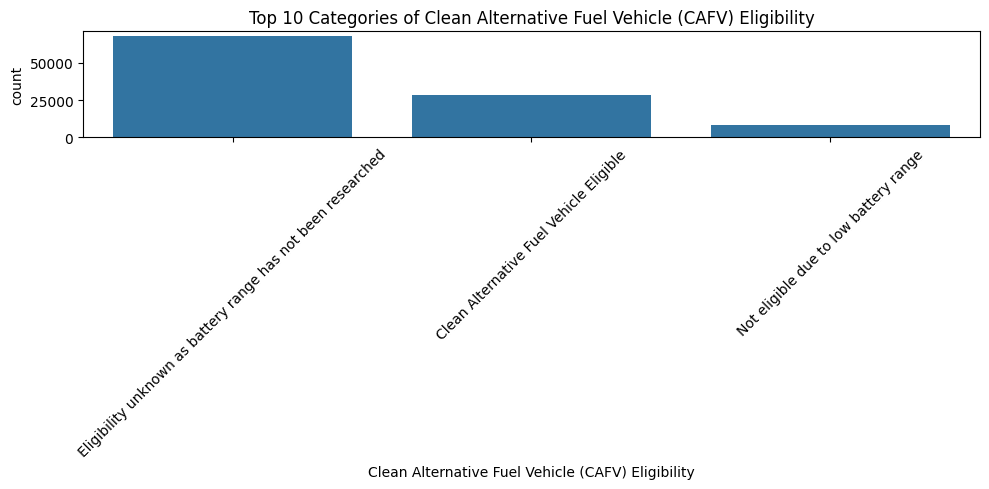

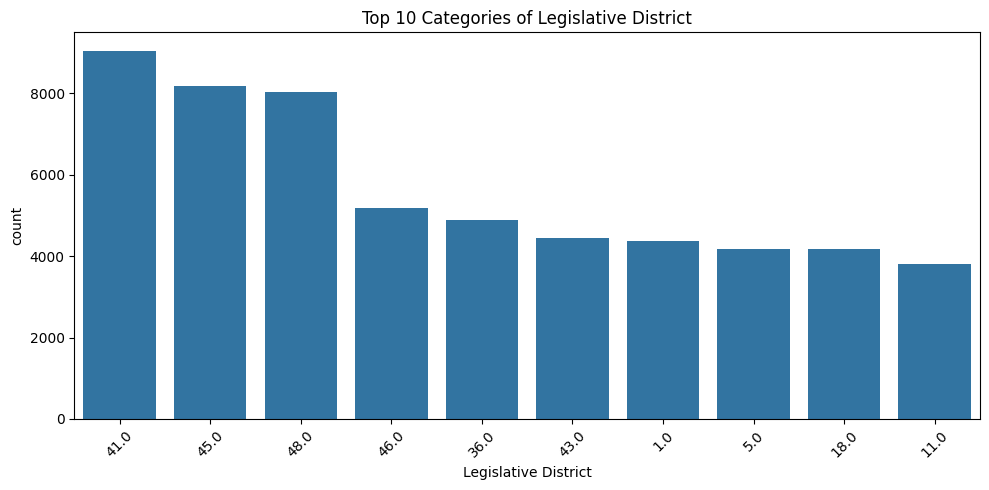

/tmp/ipykernel_722/2614859388.py:16: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


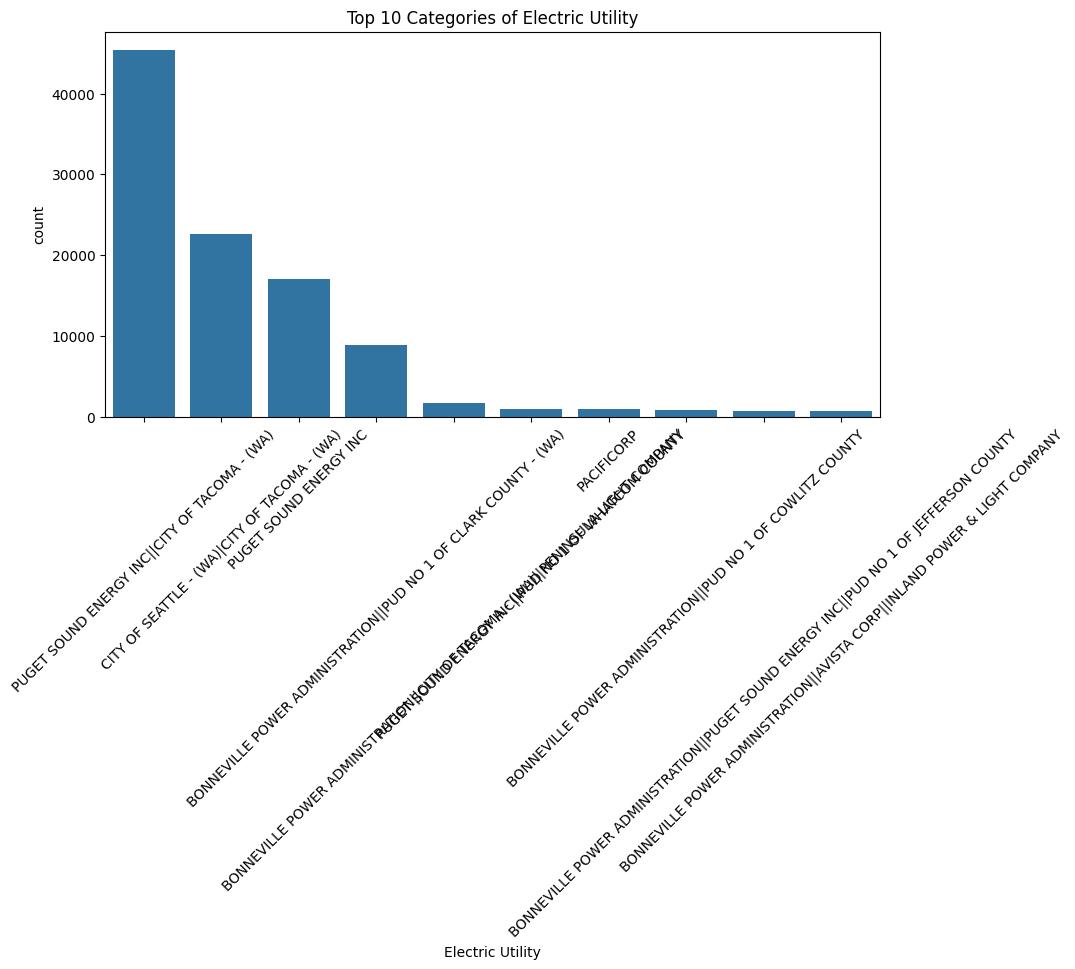

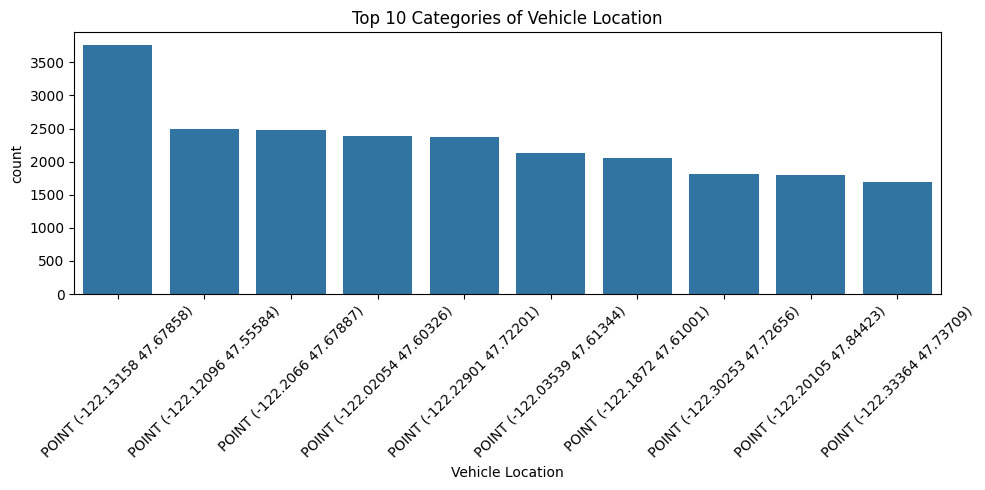

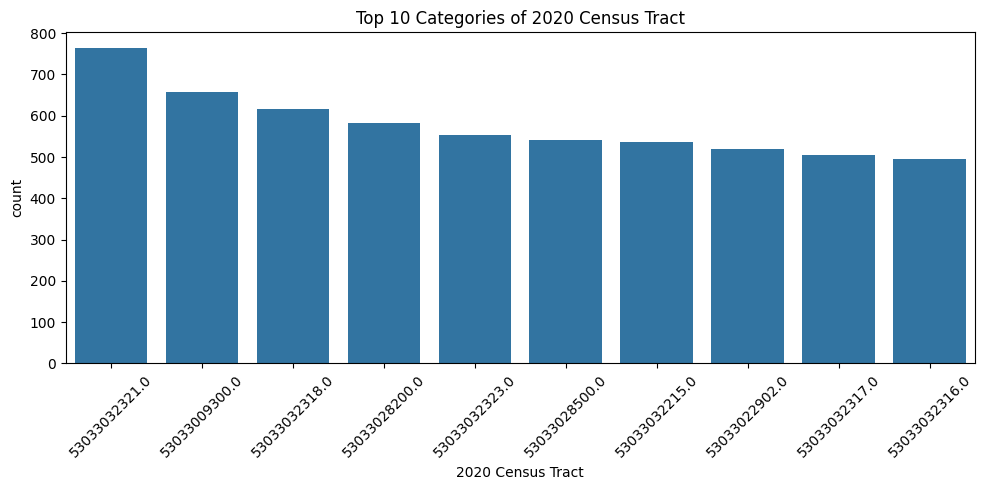

In [26]:
for col in categorical_features:

    plt.figure(figsize=(10,5))

    top10 = EV_df[col].value_counts().head(10).index

    sns.countplot(
        data=EV_df,
        x=col,
        order=top10
    )

    plt.title(f"Top 10 Categories of {col}")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

In [27]:
# From observing Categorical data we understands:
#In 'States' only one state exists this feature has no variation.

### Bivariate Analysis

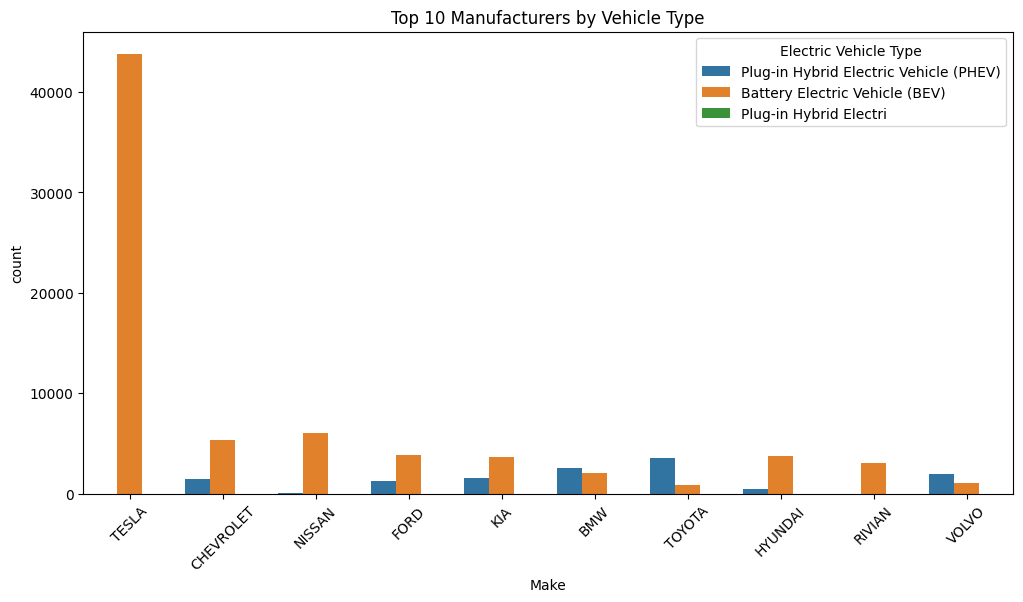

In [28]:
plt.figure(figsize=(12,6))

top10 = EV_df["Make"].value_counts().head(10).index

sns.countplot(
    data=EV_df[EV_df["Make"].isin(top10)],
    x="Make",
    hue="Electric Vehicle Type",
    order=top10
)

plt.xticks(rotation=45)
plt.title("Top 10 Manufacturers by Vehicle Type")
plt.show()

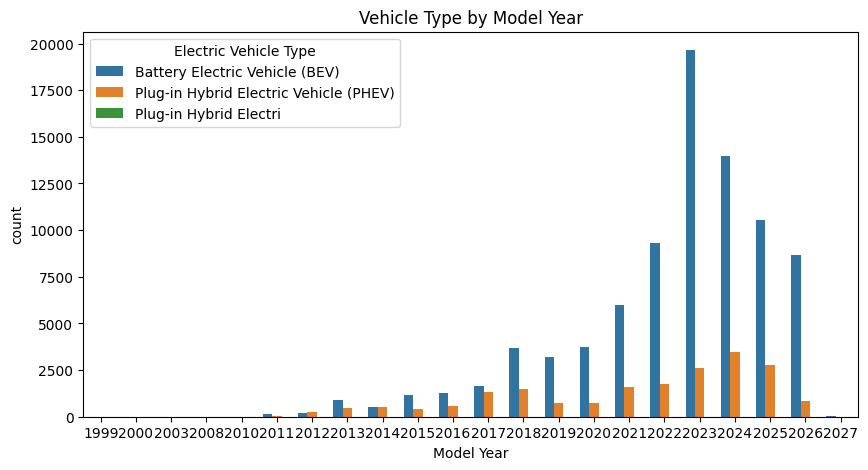

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=EV_df,
    x="Model Year",
    hue="Electric Vehicle Type"
)

plt.title("Vehicle Type by Model Year")
plt.show()

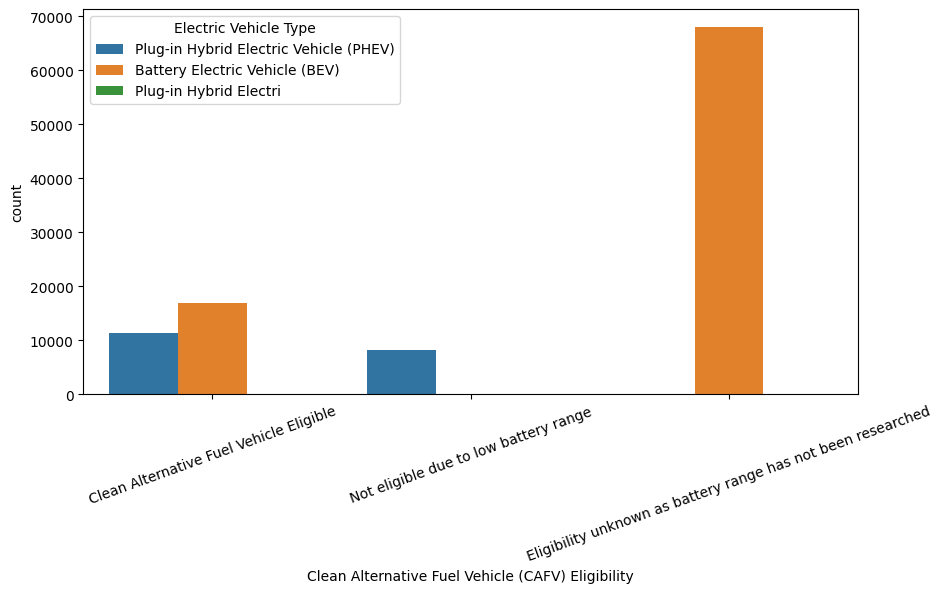

In [30]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=EV_df,
    x="Clean Alternative Fuel Vehicle (CAFV) Eligibility",
    hue="Electric Vehicle Type"
)

plt.xticks(rotation=20)
plt.show()

In [31]:
#Model Year is strongly associated with Electric Vehicle Type and should be retained as a predictive feature.

### correlaton heatmap

In [32]:
#A correlation heatmap was not generated because the dataset contains only one continuous numerical feature

# Data preprocessing

## Data Cleaning

In [33]:
# Removing (VIN (1-10), DOL Vehicle ID)-Identifiers no importance in prediction.
# State - Unique Value repeated.
# Vehicle Location - Too many unique values
# 2020 Census tract,Postal code - Behaves like a identifier

In [34]:
drop_cols = [
    "VIN (1-10)",
    "DOL Vehicle ID",
    "State",
    "Vehicle Location","Postal Code",
    "2020 Census Tract"
]

EV_df = EV_df.drop(columns=drop_cols)

### Missing Value Handling

In [35]:
EV_df.isnull().sum()  #Check missing values

,0
County,2
City,2
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,1
Electric Range,4
Legislative District,26
Electric Utility,3


In [36]:
missing = EV_df.isnull().sum()

missing_percentage = (missing / len(EV_df)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
}).sort_values("Missing Values", ascending=False)

,Missing Values,Percentage
Legislative District,26,0.024950
Electric Range,4,0.003838
Electric Utility,3,0.002879
County,2,0.001919
City,2,0.001919
Clean Alternative Fuel Vehicle (CAFV) Eligibility,1,0.000960
Electric Vehicle Type,0,0.000000
Model,0,0.000000
Make,0,0.000000
Model Year,0,0.000000


In [37]:
# Fill categorical columns with mode
cat_fill = [
    "County",
    "City",
    "Electric Utility",
    "Legislative District"
]

for col in cat_fill:
    EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)
EV_df.isnull().sum()



/tmp/ipykernel_722/876020920.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)


,0
County,0
City,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,1
Electric Range,4
Legislative District,0
Electric Utility,0


In [38]:
for col in cat_fill:
    EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)

# Fill numerical column with median
EV_df["Electric Range"].fillna(
    EV_df["Electric Range"].median(),
    inplace=True
)
EV_df.isnull().sum()

/tmp/ipykernel_722/4250564942.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  EV_df[col].fillna(EV_df[col].mode()[0], inplace=True)
/tmp/ipykernel_722/4250564942.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

,0
County,0
City,0
Model Year,0
Make,0
Model,0
Electric Vehicle Type,0
Clean Alternative Fuel Vehicle (CAFV) Eligibility,1
Electric Range,0
Legislative District,0
Electric Utility,0


### Handling Duplicates

In [39]:
duplicate_rows = EV_df.duplicated().sum()

print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 71888


In [40]:
EV_df = EV_df.drop_duplicates()
# Removed all duplicate columns

## Outlier Handling

In [41]:
# Using the IQR method
Q1 = EV_df['Electric Range'].quantile(0.25)
Q3 = EV_df['Electric Range'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Q1: 0.0, Q3: 38.0, IQR: 38.0
Lower bound: -57.0, Upper bound: 95.0


In [42]:
outliers = EV_df[
    (EV_df['Electric Range'] < lower_bound) |
    (EV_df['Electric Range'] > upper_bound)
]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 4399


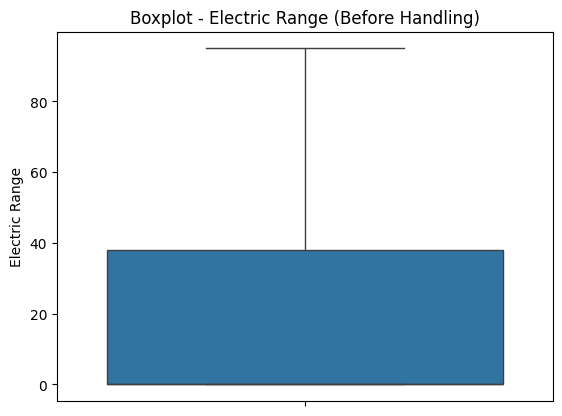

In [43]:
EV_df['Electric Range'] = EV_df['Electric Range'].clip(
    lower=lower_bound, upper=upper_bound)


# Checking whether the Outliers were clipped
sns.boxplot(EV_df['Electric Range'])
plt.title('Boxplot - Electric Range (Before Handling)')
plt.show()

# Data Transformation

## Scaling

In [44]:
# Numerical columns
num_cols = EV_df.select_dtypes(include = ['int64', 'float64']).columns
num_cols

Index(['Model Year', 'Electric Range', 'Legislative District'], dtype='object')

In [45]:
# Categorical Columns
cat_cols = EV_df.select_dtypes(include = ['object']).columns
cat_cols

Index(['County', 'City', 'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
       'Electric Utility'],
      dtype='object')

### Min-Max Scaling : Scaling technique that transforms data into a fixed range, usually 0 to 1.

In [46]:
skewed_cols =['Model Year','Electric Range']

In [47]:
# Before min max scaling
EV_df.head(2)

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,Kitsap,Bremerton,2025,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,32.0,23.0,PUGET SOUND ENERGY INC
1,Snohomish,Lynnwood,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,95.0,21.0,PUGET SOUND ENERGY INC


In [48]:
# object for min-max scaling
minmax_scaler = MinMaxScaler()
EV_df[skewed_cols] = minmax_scaler.fit_transform(EV_df[skewed_cols])

In [49]:
# After min max scaling
EV_df.head(2)

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,Kitsap,Bremerton,0.928571,VOLVO,XC90,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,0.336842,23.0,PUGET SOUND ENERGY INC
1,Snohomish,Lynnwood,0.714286,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,1.000000,21.0,PUGET SOUND ENERGY INC


## Encoding

In [50]:
# Categorical Columns
cat_cols = EV_df.select_dtypes(include = ['object']).columns
cat_cols

Index(['County', 'City', 'Make', 'Model', 'Electric Vehicle Type',
       'Clean Alternative Fuel Vehicle (CAFV) Eligibility',
       'Electric Utility'],
      dtype='object')

In [51]:
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    EV_df[col] = le.fit_transform(EV_df[col].astype(str))
    label_encoders[col] = le
EV_df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,Electric Utility
0,21,31,0.928571,45,186,2,0,0.336842,23.0,68
1,40,194,0.714286,40,107,0,0,1.000000,21.0,68
2,21,278,0.500000,14,30,2,2,0.200000,35.0,68
3,43,404,0.535714,40,108,0,0,1.000000,2.0,68
4,40,29,0.857143,40,110,0,1,0.000000,1.0,68


# Model Building

## Data Splitting


In [52]:
y = EV_df['Electric Vehicle Type']
X = EV_df.drop(columns = ['Electric Vehicle Type'], axis = 1)

# split into train-test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =33)


## Model Building Using Decision Tree

In [64]:
dt_model = DecisionTreeClassifier()
# Train the model
dt_model.fit(X_train, y_train)
# Make predictions using the model
dt_pred = dt_model.predict(X_test)
# Evaluate the model performance
acc_dt = accuracy_score(y_test, dt_pred)
recall_dt = recall_score(y_test, dt_pred, average='weighted')
precision_dt = precision_score(y_test, dt_pred, average='weighted')
f1_dt = f1_score(y_test, dt_pred, average='weighted')
print(" Accuracy of Decision Tree: ", acc_dt)
print(" Recall of Decision Tree: ", recall_dt)
print(" Precision of Decision Tree: ", precision_dt)
print(" F1 Score of Decision Tree: ", f1_dt)

 Accuracy of Decision Tree:  0.9973704563031709
 Recall of Decision Tree:  0.9973704563031709
 Precision of Decision Tree:  0.9973708311756587
 F1 Score of Decision Tree:  0.9973706166374466


## Cross Validation of Decision Tree

### k-fold Cross Validation

In [56]:
kf_obj = KFold(n_splits = 5, shuffle = True)

scores = cross_val_score(DecisionTreeClassifier(), X, y, cv = kf_obj)
print('Cross validation scores:',scores)
# print('Mean of cv scores:', np.mean(scores))
print('Mean of cv scores:', scores.mean())
print('Minimum cv:', scores.min())
print('Maximum cv:', scores.max())
diff = scores.max() - scores.min()
print('Difference b/w min and max cv:', diff)


Cross validation scores: [0.99644238 0.99752514 0.99752475 0.99628713 0.99752475]
Mean of cv scores: 0.9970608302129517
Minimum cv: 0.9962871287128713
Maximum cv: 0.9975251353441609
Difference b/w min and max cv: 0.0012380066312895899


### Grid Search Cross Validation

In [65]:
# Define the parameters you want to check
para_grid = {'criterion': ['gini','entropy'],
             'max_depth': [2,3,4,5,6],
              'min_samples_split': [2,4,6]}

# build the model obj
grid = GridSearchCV(DecisionTreeClassifier(), para_grid, cv = 5, scoring = 'accuracy')


# train the model
grid.fit(X_train, y_train)

print('Best parameters are: ', grid.best_params_)
print('Best cross validation score is: ', grid.best_score_)


# We build the model using the best parameters identified
dT_model_HPT = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, min_samples_split = 2)

# Train the model
dT_model_HPT.fit(X_train, y_train)
# Make predictions using the model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)
# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)
print('Accuracy :', acc_dT_HPT)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best parameters are:  {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
Best cross validation score is:  0.9979889555993978
Accuracy : 0.9924207269914926


### Randomized Search Cross Validation

In [61]:
# Define the parameters to check
para_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6]
}

# Build the model object
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=para_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the model
random_search.fit(X_train, y_train)

# Display the best parameters and score
print('Best parameters are:', random_search.best_params_)
print('Best cross validation score is:', random_search.best_score_)

# Build the model using the best parameters
dT_model_HPT = random_search.best_estimator_

# Make predictions using the model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)

# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)

print('Accuracy:', acc_dT_HPT)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best parameters are: {'min_samples_split': 2, 'max_depth': 6, 'criterion': 'entropy'}
Best cross validation score is: 0.9979889555993978
Accuracy: 0.9979891724671307
